<a href="https://colab.research.google.com/github/mahmooda23/Early-Risk-Stratification-of-Maternal-Complications-during-Pregnancy-/blob/main/predict_risk_during_pregnancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [1]:
import pandas as pd
from google.colab import files


uploaded = files.upload()
file_name = 'MaternalHealthRiskDataset.csv'
if file_name in uploaded.keys():
  print(f'Successfully uploaded "{file_name}"')


  # Read the CSV file into a pandas DataFrame
  df = pd.read_csv(file_name)
  print("\nFirst 5 rows of the uploaded data:")
  display(df.head())

else:
  print(f'Error: "{file_name}" was not uploaded. Please ensure you select the correct file.')


Saving MaternalHealthRiskDataset.csv to MaternalHealthRiskDataset.csv
Successfully uploaded "MaternalHealthRiskDataset.csv"

First 5 rows of the uploaded data:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [71]:
# Re-load the DataFrame directly from the CSV to ensure RiskLevel is in its original string format.
df = pd.read_csv(file_name)
print("DataFrame reloaded from CSV. First 5 rows:")
display(df.head())

DataFrame reloaded from CSV. First 5 rows:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [72]:
df.shape


(1014, 7)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [74]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [75]:
df.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0


In [76]:
df.duplicated().sum()

np.int64(562)

In [77]:
# Remove duplicate rows from the DataFrame
df.drop_duplicates(inplace=True, keep='first')

print(f"DataFrame shape after removing duplicates: {df.shape}")
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")

DataFrame shape after removing duplicates: (452, 7)
Number of duplicate rows after removal: 0


In [79]:
df.head(10)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.00,98.0,86,high risk
1,35,140,90,13.00,98.0,70,high risk
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
6,23,130,70,7.01,98.0,78,mid risk
7,35,85,60,11.00,102.0,86,high risk
8,32,120,90,6.90,98.0,70,mid risk
9,42,130,80,18.00,98.0,70,high risk


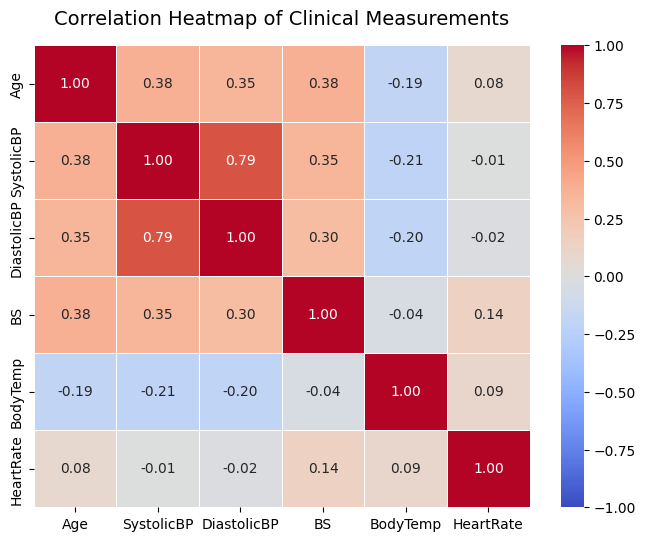

In [80]:

# 1. Correlation Heatmap (Feature-to-Feature)

plt.figure(figsize=(8, 6))

# use numeric_only = True so it ignores the text-based RiskLevel column
correlation_matrix = df.corr(numeric_only=True)

# Generate the heatmap
# annot=True puts the exact correlation numbers inside the squares

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Measurements', pad=15, fontsize=14)
plt.show()



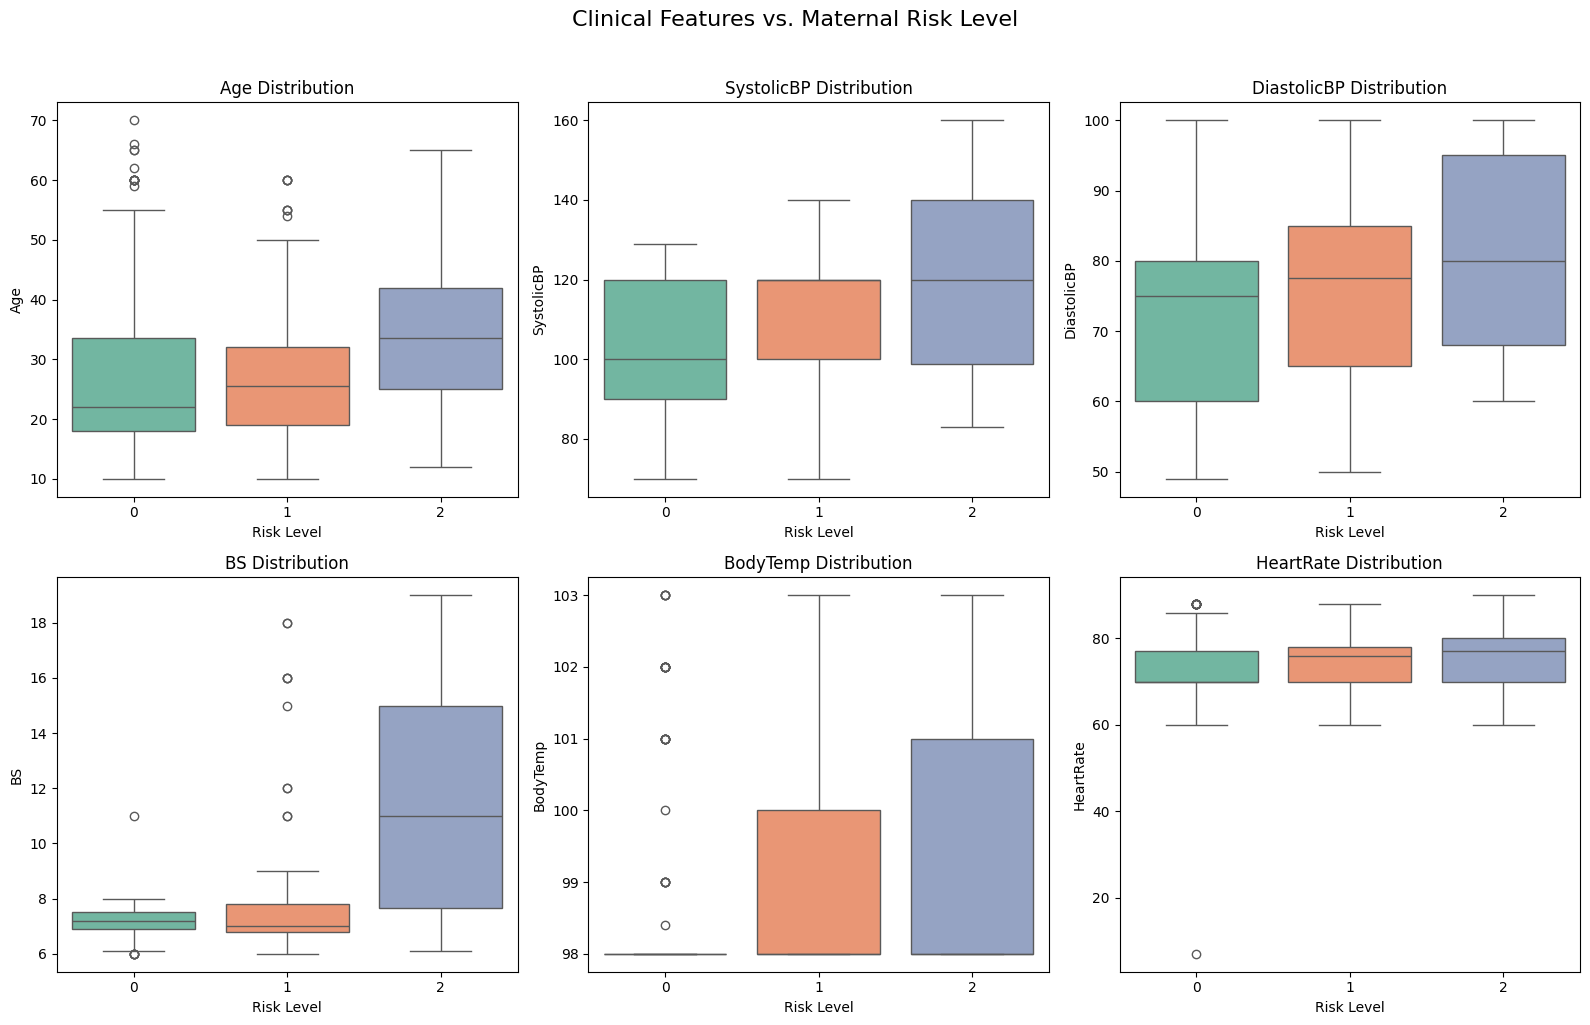

In [84]:
# 2. Boxplots (Feature-to-Target)
# List of 6 numerical columns

# Clean the RiskLevel column: strip whitespace and convert to lowercase
df['RiskLevel'] = df['RiskLevel'].str.strip().str.lower()

# Now, apply the mapping
risk_level_mapping = {
    'low risk': 0,
    'mid risk': 1,
    'high risk': 2
}
df['RiskLevel'] = df['RiskLevel'].map(risk_level_mapping)

features = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

# Create a 2x3 grid for the plots so they display cleanly together

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Clinical Features vs. Maternal Risk Level', fontsize=16, y=1.02)

# Flatten the 2D grid of axes into a 1D array so we can loop through it easily

axes = axes.flatten()

# Lock the order from Low to High for clinical readability
# Note: If you already ran your encoding step, change this to: risk_order = [0, 1, 2]

risk_order = [0, 1, 2]

# Loop through each feature and create a boxplot in its respective grid spot

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='RiskLevel', y=feature, order=risk_order, ax=axes[i], palette='Set2', hue='RiskLevel', legend=False)
    axes[i].set_title(f'{feature} Distribution', fontsize=12)
    axes[i].set_ylabel(feature)
    axes[i].set_xlabel('Risk Level')

# Automatically adjust spacing so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [85]:
df['RiskLevel'].value_counts()

,count
RiskLevel,
0,234
2,112
1,106


In [86]:
#encode the categorical variables

risk_level_mapping = {
    'low risk': 0,
    'mid risk': 1,
    'high risk': 2
}
df['RiskLevel'] = df['RiskLevel'].map(risk_level_mapping)

print("RiskLevel column after mapping:")
print(df['RiskLevel'].value_counts())
print("\nFirst 5 rows of the DataFrame with numerical RiskLevel:")
display(df.head())

RiskLevel column after mapping:
Series([], Name: count, dtype: int64)

First 5 rows of the DataFrame with numerical RiskLevel:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,NaN
1,35,140,90,13.0,98.0,70,NaN
2,29,90,70,8.0,100.0,80,NaN
3,30,140,85,7.0,98.0,70,NaN
4,35,120,60,6.1,98.0,76,NaN


In [69]:
# Clean the RiskLevel column: strip whitespace and convert to lowercase
df['RiskLevel'] = df['RiskLevel'].str.strip().str.lower()

# Display value counts to verify cleaning (optional)
print("RiskLevel column value counts after cleaning:")
print(df['RiskLevel'].value_counts())

# Now, apply the mapping
risk_level_mapping = {
    'low risk': 0,
    'mid risk': 1,
    'high risk': 2
}
df['RiskLevel'] = df['RiskLevel'].map(risk_level_mapping)

print("\nRiskLevel column after mapping:")
print(df['RiskLevel'].value_counts())
print("\nFirst 5 rows of the DataFrame with numerical RiskLevel:")
display(df.head())

RiskLevel column value counts after cleaning:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

RiskLevel column after mapping:
RiskLevel
0    406
1    336
2    272
Name: count, dtype: int64

First 5 rows of the DataFrame with numerical RiskLevel:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


In [65]:
# 1. Isolate Features (X) and Target (y)
# X contains all clinical measurements; y contains what I am trying to predict

X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# 2. Perform the Split
# I use 80% of the data to train the model, and hold back 20% to test it.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# 3. Verify the split (Great to include in a project report)

print(f"Total patients: {len(df)}")
print(f"Patients in Training Set: {len(X_train)}")
print(f"Patients in Testing Set: {len(X_test)}")

ValueError: Input y contains NaN.

In [31]:
# Initialize the StandardScaler

scaler = StandardScaler()

# Fit the scaler to the training data and transform both training and testing data

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier viewing and consistency

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


print("X_train_scaled (first 5 rows):")

display(X_train_scaled_df.head())


print("\nX_test_scaled (first 5 rows):")

display(X_test_scaled_df.head())

X_train_scaled (first 5 rows):


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
617,0.080577,0.374243,-1.181324,-0.797921,-0.483511,0.227772
774,-0.512148,0.374243,0.994093,-0.267172,-0.483511,-1.706505
610,-1.253054,-1.254035,-0.818754,-0.360834,1.703072,0.711342
525,0.895574,0.374243,0.268954,-0.360834,-0.483511,-0.497581
70,-0.289876,-1.525415,-1.181324,-0.829142,1.703072,1.436696



X_test_scaled (first 5 rows):


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
71,-0.067604,0.917002,-0.456185,-0.298393,-0.483511,0.469557
141,-0.956692,-1.254035,-1.181324,-0.548157,1.703072,0.227772
918,1.488299,0.374243,0.268954,-0.360834,-0.483511,-0.497581
491,-0.512148,0.374243,0.994093,-0.235952,-0.483511,-0.497581
878,0.154668,0.374243,0.994093,-0.579378,-0.483511,-0.497581


In [36]:
# 1. Initialize a dictionary of 5 different models
# We use class_weight='balanced' wherever possible to protect against class bias

models_scaled = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(class_weight='balanced', probability=True, random_state=42)
}


# 2. Loop through the models, train them, and evaluate them using scaled data

results_scaled = []
print("Training models with scaled data...")

for name, model in models_scaled.items():

    # Train the model using scaled training data
    model.fit(X_train_scaled_df, y_train)

    # Make predictions on the unseen scaled test data
    y_pred_scaled = model.predict(X_test_scaled_df)

    # Calculate both Accuracy and Macro Recall
    acc_scaled = accuracy_score(y_test, y_pred_scaled)
    macro_recall_scaled = recall_score(y_test, y_pred_scaled, average='macro')

    # Save the results
    results_scaled.append({
        "Model": name,
        "Accuracy (%)": round(acc_scaled * 100, 2),
        "Macro Recall (%)": round(macro_recall_scaled * 100, 2)
    })

# 3. Create a comparison table and sort it by Macro Recall (the most important metric)
comparison_df_scaled = pd.DataFrame(results_scaled).sort_values(by="Macro Recall (%)", ascending=False)

print("\n--- Final Model Comparison with Scaled Data ---")
print(comparison_df_scaled.to_string(index=False))

Training models with scaled data...

--- Final Model Comparison with Scaled Data ---
                 Model  Accuracy (%)  Macro Recall (%)
         Random Forest         85.71             86.56
     Gradient Boosting         82.76             83.47
         Decision Tree         81.77             83.07
Support Vector Machine         69.46             69.82
   Logistic Regression         63.05             64.23


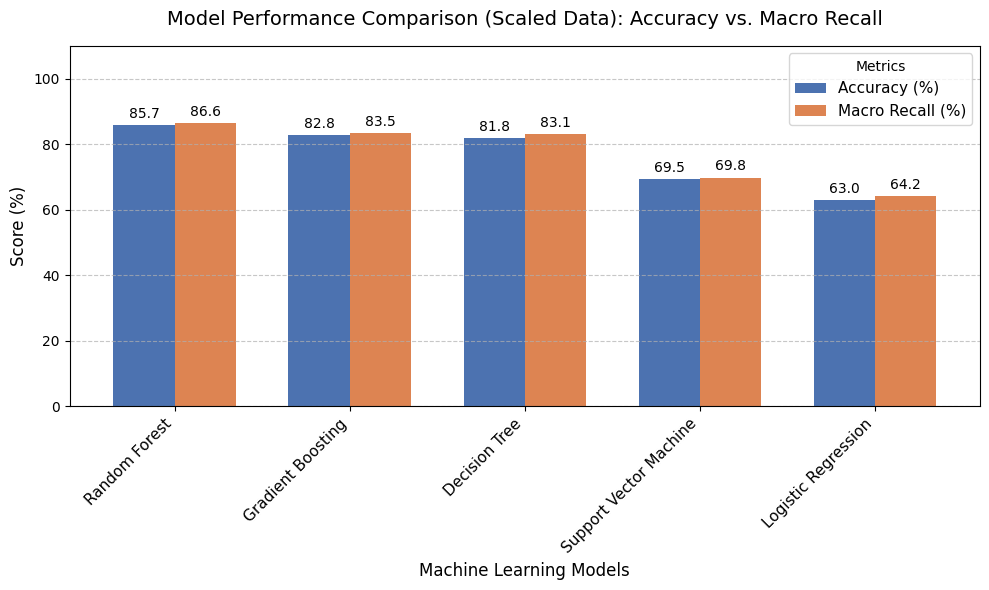

In [37]:
# 1. Set the 'Model' column as the index so it becomes the X-axis labels

plot_df_scaled = comparison_df_scaled.set_index('Model')

# 2. Create the grouped bar chart
ax_scaled = plot_df_scaled.plot(kind='bar', figsize=(10, 6), width=0.7, color=['#4C72B0', '#DD8452'])

# 3. Add titles and labels
plt.title('Model Performance Comparison (Scaled Data): Accuracy vs. Macro Recall', fontsize=14, pad=15)
plt.ylabel('Score (%)', fontsize=12)
plt.xlabel('Machine Learning Models', fontsize=12)

# 4. Formatting to make it presentation-ready
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylim(0, 110) # Set Y-axis slightly above 100 to make room for the legend
plt.legend(title='Metrics', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Add the exact numbers on top of the bars for clarity
for container in ax_scaled.containers:
    ax_scaled.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

# 6. Adjust layout so the labels don't get cut off, then display
plt.tight_layout()
plt.show()

--- Detailed Clinical Evaluation (Random Forest - Scaled Data) ---
              precision    recall  f1-score   support

           0       0.87      0.83      0.85        81
           1       0.81      0.81      0.81        67
           2       0.90      0.96      0.93        55

    accuracy                           0.86       203
   macro avg       0.86      0.87      0.86       203
weighted avg       0.86      0.86      0.86       203



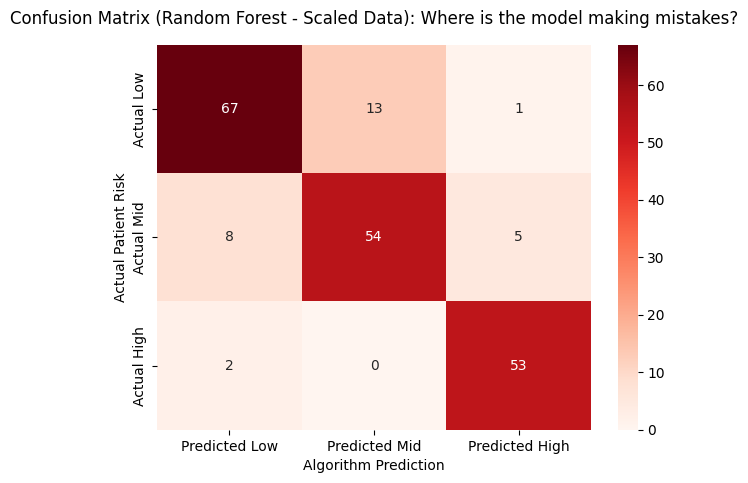

In [38]:
# Identify the best performing model from the scaled results
best_model_name_scaled = comparison_df_scaled.iloc[0]['Model']
best_model_scaled = models_scaled[best_model_name_scaled]

# 1. Generate final predictions using the winning model with scaled data
y_pred_best_scaled = best_model_scaled.predict(X_test_scaled_df)

# 2. Print the detailed Classification Report
print(f"--- Detailed Clinical Evaluation ({best_model_name_scaled} - Scaled Data) ---")
print(classification_report(y_test, y_pred_best_scaled))


# 3. Plot the Confusion Matrix
cm_scaled = confusion_matrix(y_test, y_pred_best_scaled, labels=[0, 1, 2])

plt.figure(figsize=(7, 5))
sns.heatmap(cm_scaled, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Low', 'Predicted Mid', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual Mid', 'Actual High'])
plt.title(f'Confusion Matrix ({best_model_name_scaled} - Scaled Data): Where is the model making mistakes?', pad=15)
plt.ylabel('Actual Patient Risk')
plt.xlabel('Algorithm Prediction')
plt.show()

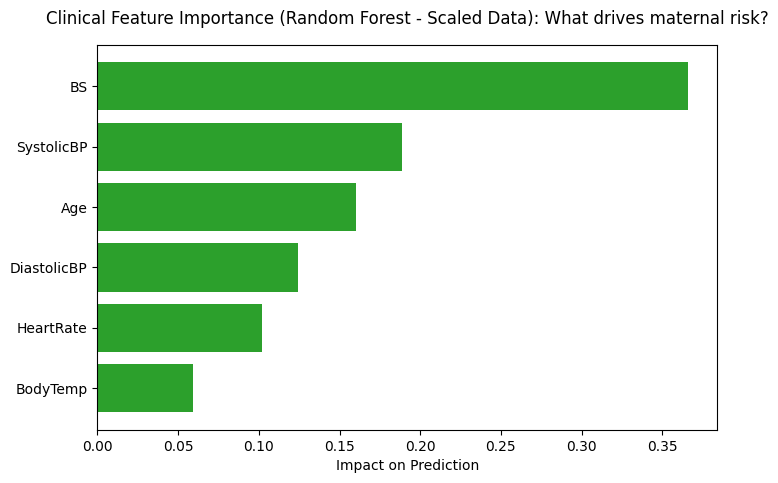

In [39]:
# 4. Plot Clinical Feature Importance for the best model with scaled data

# Only tree-based models have feature_importances_. SVC does not.
if hasattr(best_model_scaled, 'feature_importances_'):
    feature_importances_scaled = best_model_scaled.feature_importances_
    features = X.columns

    importance_df_scaled = pd.DataFrame({'Feature': features, 'Importance': feature_importances_scaled})
    importance_df_scaled = importance_df_scaled.sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(importance_df_scaled['Feature'], importance_df_scaled['Importance'], color='#2ca02c')
    plt.title(f'Clinical Feature Importance ({best_model_name_scaled} - Scaled Data): What drives maternal risk?', pad=15)
    plt.xlabel('Impact on Prediction')
    plt.show()
else:
    print(f"Feature importance is not available for {best_model_name_scaled}.")

In [40]:
# Initialize Stratified K-Fold Cross-Validation
# We'll use 5 splits (folds) to balance computational cost and robust estimation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
print("Performing Stratified K-Fold Cross-Validation on scaled data...")

for name, model in models_scaled.items():
    # Lists to store scores for each fold
    fold_accuracies = []
    fold_macro_recalls = []

    # Iterate through each fold
    for fold_idx, (train_index, val_index) in enumerate(skf.split(X_train_scaled_df, y_train)):
        X_train_fold, X_val_fold = X_train_scaled_df.iloc[train_index], X_train_scaled_df.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        # Train the model on the training fold
        model.fit(X_train_fold, y_train_fold)

        # Make predictions on the validation fold
        y_pred_fold = model.predict(X_val_fold)

        # Calculate metrics for the current fold
        fold_accuracies.append(accuracy_score(y_val_fold, y_pred_fold))
        fold_macro_recalls.append(recall_score(y_val_fold, y_pred_fold, average='macro'))

    # Store the average results across all folds
    cv_results.append({
        "Model": name,
        "Mean Accuracy (%)": round(np.mean(fold_accuracies) * 100, 2),
        "Mean Macro Recall (%)": round(np.mean(fold_macro_recalls) * 100, 2),
        "Std. Dev. Accuracy": round(np.std(fold_accuracies) * 100, 2),
        "Std. Dev. Macro Recall": round(np.std(fold_macro_recalls) * 100, 2)
    })

# Create a comparison table for CV results
cv_comparison_df = pd.DataFrame(cv_results).sort_values(by="Mean Macro Recall (%)", ascending=False)

print("\n--- K-Fold Cross-Validation Results (Scaled Data) ---")
print(cv_comparison_df.to_string(index=False))

Performing Stratified K-Fold Cross-Validation on scaled data...

--- K-Fold Cross-Validation Results (Scaled Data) ---
                 Model  Mean Accuracy (%)  Mean Macro Recall (%)  Std. Dev. Accuracy  Std. Dev. Macro Recall
         Random Forest              83.60                  84.28                2.71                    2.33
         Decision Tree              82.12                  83.17                2.73                    2.26
     Gradient Boosting              79.16                  79.67                2.60                    2.41
Support Vector Machine              69.17                  68.81                3.27                    3.41
   Logistic Regression              59.80                  60.15                4.12                    3.95


--- AUC-ROC Analysis for Random Forest ---


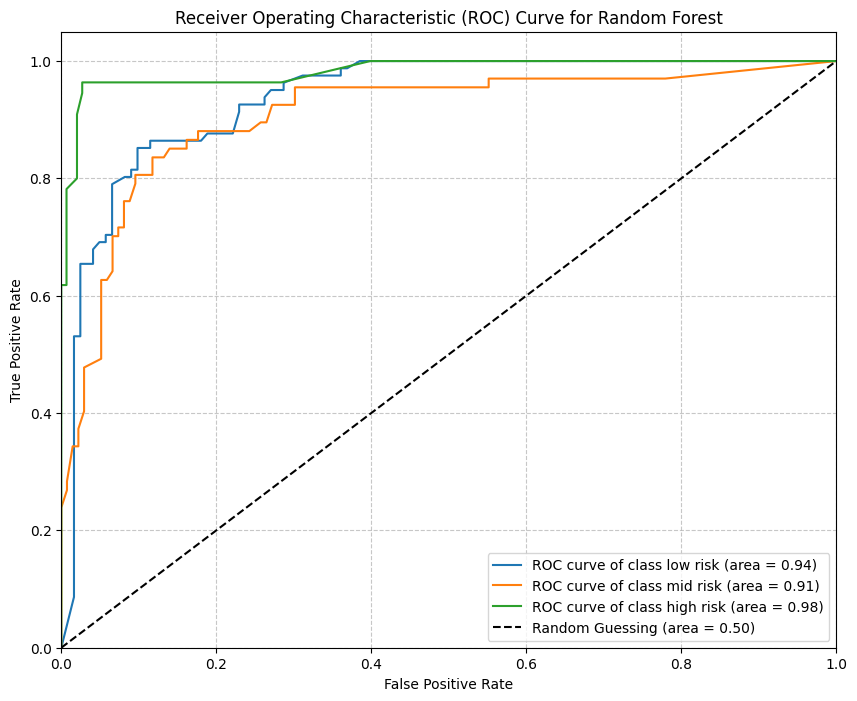

In [50]:


print(f"--- AUC-ROC Analysis for {best_model_name_scaled} ---")

# Ensure the best_model_scaled is the Random Forest Classifier
# Assuming `best_model_scaled` is already the trained Random Forest model
# Get predicted probabilities for each class
y_pred_proba_scaled = best_model_scaled.predict_proba(X_test_scaled_df)

# Binarize the true labels for multi-class AUC calculation
# Map back to 'low risk', 'mid risk', 'high risk' for correct ordering in label_binarize
risk_level_reverse_mapping = {0: 'low risk', 1: 'mid risk', 2: 'high risk'}
y_test_labels = y_test.map(risk_level_reverse_mapping)
class_labels = ['low risk', 'mid risk', 'high risk']
y_test_binarized = label_binarize(y_test_labels, classes=class_labels)

# Compute ROC curve and AUC for each class
plt.figure(figsize=(10, 8))
for i, class_label in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_pred_proba_scaled[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_label} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (area = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Receiver Operating Characteristic (ROC) Curve for {best_model_name_scaled}')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()